In [38]:
import pandas as pd
import torch
import transformers
from torch.utils.data import Dataset
import os
import numpy as np
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
combined = pd.read_csv('combined_df_regions.csv')

In [40]:
combined.drop(columns={'Unnamed: 0'}, inplace=True)

In [41]:
pos = (combined['Pathogenicity']==1).sum()
neg = (combined['Pathogenicity']==0).sum()

pos/neg

np.float64(0.06861190761905023)

In [42]:
folder = '/blue/egn6933/apatil2/embeddings/'

files = sorted([f for f in os.listdir(folder) if f.endswith('.pt')])

train_files_temp, test_files = train_test_split(
    files,
    test_size=0.2,
    random_state=42
)

# print(len(train_files), len(test_files))

train_files, val_files = train_test_split(
    train_files_temp,
    test_size=0.25,
    random_state=42
)

print(len(train_files), len(val_files), len(test_files))

1833 611 611


In [43]:
#function to extract the starting index
def get_file_idx(f):
    return int(f.split('_')[-1].replace('.pt',''))

In [44]:
#saving the indices in the test set in a list
test_indices = []
start_indices = []
for f in test_files:
    start = get_file_idx(f)
    end = start+256
    test_indices.extend(range(start, end))
    start_indices.append(int(f.split('_')[-1].replace('.pt','')))

In [45]:
#filtering out the test rows from the main dataframe
combined_test = combined.iloc[test_indices].reset_index(drop=True)

In [46]:
# define the dataset class
class EmbeddingDataset(Dataset):
    
    def __init__(self, folder, files):
        self.folder = folder
        self.files = files
    
    def __len__(self):
        
        return len(self.files)
    
    def __getitem__(self, idx):
        
        batch = torch.load(os.path.join(self.folder, self.files[idx]))
        X = batch['X'][:, 64, :]
        y = batch['Y']
        
        return X, y                        

In [47]:
# define the data loader

train_dataset = EmbeddingDataset(folder, train_files)
val_dataset = EmbeddingDataset(folder, val_files)
test_dataset = EmbeddingDataset(folder, test_files)

train_loader = DataLoader(train_dataset, batch_size = 1, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 1, shuffle = False)

In [48]:
import torch.nn as nn

class MLP(nn.Module):
    
    def __init__(self):
        super().__init__()
    
        self.model = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        x = torch.nn.functional.normalize(x, dim=1)
        return self.model(x)
    

In [49]:
#complex model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model1 = MLP().to(device)

#using weighted loss function
weights = torch.sqrt(torch.tensor([neg/pos])).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight = weights)

#early stopping threshold
threshold = 3e-3
prev_loss = float('inf')
patience = 3
patience_counter = 0

initial_rate = 2e-4
optimizer = torch.optim.Adam(
    model1.parameters(),
    lr = initial_rate
)

scheduler = lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

epoch = 50

In [50]:
def compute_accuracy(preds, labels, threshold = 0.5):
    preds = torch.sigmoid(preds)
    preds = (preds>threshold).float()
    
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    
    return correct, total

In [51]:
def compute_precision(preds, labels, threshold = 0.5):
    preds = torch.sigmoid(preds)
    preds = (preds>threshold).float()
    
    true_positive = ((preds==1.0) & (labels==1.0)).sum().item()
    false_positive = ((preds==1.0) & (labels==0.0)).sum().item()
    
    return true_positive, false_positive

In [52]:
def compute_recall(preds, labels, threshold = 0.5):
    preds = torch.sigmoid(preds)
    preds = (preds>threshold).float()
    
    false_negative = ((preds==0.0) & (labels==1.0)).sum().item()
    return false_negative

In [53]:
# #Load the saved model weights
# path = '/blue/egn6933/apatil2/model_checkpoints/complex_model_val/model_epoch_21.pt'

# checkpoint = torch.load(path)


In [54]:
#load the parameters into the MLP instance
# model1.load_state_dict(checkpoint)

In [55]:
# training loop

train_loss = []
train_acc = []
train_precision = []
train_recall = []

val_l = []
val_acc = []
val_precision = []
val_recall = []
val_mcc_list = []

thresholds=[]
for i in range(epoch):
    model1.train()
    
    total_correct = 0
    total_samples = 0
    total_loss = 0
    total_true_positive = 0
    total_false_positive = 0
    total_false_negative = 0
    
    val_total_correct = 0
    val_total_samples = 0
    val_total_loss = 0
    val_total_true_positive = 0
    val_total_false_positive = 0
    val_total_false_negative = 0
    
    for X,y in train_loader:
        
        #reshaping the input embeddings and converting the labels to float
        X = X.squeeze().to(device)
        y = y.squeeze().float().to(device)
        
        #setting the previous gradients to zero
        optimizer.zero_grad()
        
        #getting the output from the model
        output = model1(X).squeeze()
        
        #calculating the loss
        loss = criterion(output, y)
        
        #backpropagation step
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        #computing the accuracy 
        correct, total = compute_accuracy(output, y)
        total_correct += correct
        total_samples += total
        
        #computing the precision 
        true_positive, false_positive = compute_precision(output, y)
        total_true_positive += true_positive
        total_false_positive += false_positive
        
        #computing the recall 
        false_negative = compute_recall(output, y)
        total_false_negative += false_negative
        
    model1.eval()
    val_loss = 0.0
    
    #disabling gradient calculation
    with torch.no_grad():
        for X,y in val_loader:
            X = X.squeeze().to(device)
            y = y.squeeze().float().to(device)
            
            output = model1(X).squeeze()
            
            loss = criterion(output, y)
            
            val_loss+=loss.item()
            
            # temp_true_positives = 0
            # best_t=0
            
#             for t in range(0.35,0.5,0.03):
                
#                 #val precision
#                 true_positive, false_positive = compute_precision(output, y, t)
#                 val_total_true_positive += true_positive
                
#                 if val_total_true_positive>temp_true_positive:
#                     temp_true_positive=val_total_true_positive
#                     best_t = t
            
#             thresholds.append(best_t)
                    
                
            #val accuracy
            val_correct, val_total = compute_accuracy(output, y)
            val_total_correct += val_correct
            val_total_samples += val_total

            #val precision
            true_positive, false_positive = compute_precision(output, y)
            val_total_true_positive += true_positive
            val_total_false_positive += false_positive

            #val recall 
            false_negative = compute_recall(output, y)
            val_total_false_negative += false_negative

        tn = val_total_samples - (val_total_true_positive + val_total_false_positive + val_total_false_negative)

        numerator = (val_total_true_positive * tn) - (val_total_false_positive * val_total_false_negative)

        denominator = (
            (val_total_true_positive + val_total_false_positive) *
            (val_total_true_positive + val_total_false_negative) *
            (tn + val_total_false_positive) *
            (tn + val_total_false_negative)
        ) ** 0.5 + 1e-8

        val_mcc = numerator / denominator
        val_mcc_list.append(val_mcc)
        
    #updating the learning rate
    scheduler.step()
    
    #metrics calculation per epoch
    #train
    epoch_acc = total_correct / total_samples
    epoch_precision = total_true_positive/(total_true_positive+total_false_positive)
    epoch_recall = total_true_positive/(total_true_positive+total_false_negative)
    epoch_loss = total_loss/len(train_loader)
    
    #val
    val_epoch_acc = val_total_correct / val_total_samples
    val_epoch_precision = val_total_true_positive/(val_total_true_positive+val_total_false_positive)
    val_epoch_recall = val_total_true_positive/(val_total_true_positive+val_total_false_negative)
    val_epoch_loss = val_loss/len(val_loader)
    
    #storing the metrics as per the epoch
    #train set
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)
    train_precision.append(epoch_precision)
    train_recall.append(epoch_recall)
    print(f"Epoch {i+1} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f} | Precision: {epoch_precision:.4f} | Recall: {epoch_recall:.4f}")
    
    #val set
    val_l.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)
    val_precision.append(val_epoch_precision)
    val_recall.append(val_epoch_recall)
    print(f"Epoch {i+1} | Val Loss: {val_epoch_loss:.4f} | Val Accuracy: {val_epoch_acc:.4f} | Val Precision: {val_epoch_precision:.4f} | Val Recall: {val_epoch_recall:.4f}")
    
    #saving the model
    torch.save(
        model1.state_dict(),
        f"/blue/egn6933/apatil2/model_checkpoints/complex_model_val/model_epoch_{i+1}.pt"
    )
    
    #early stopping logic
    if abs(prev_loss-epoch_loss)<threshold:
        patience_counter += 1
    
    else:
        patience_counter = 0
        
    if patience_counter>patience:
        print('Stopping early: converged')
        break
    
    prev_loss = epoch_loss



Epoch 1 | Loss: 0.4881 | Accuracy: 0.9156 | Precision: 0.3146 | Recall: 0.2637
Epoch 1 | Val Loss: 0.4619 | Val Accuracy: 0.9032 | Val Precision: 0.3033 | Val Recall: 0.3962
Epoch 2 | Loss: 0.4582 | Accuracy: 0.9097 | Precision: 0.3252 | Recall: 0.3735
Epoch 2 | Val Loss: 0.4516 | Val Accuracy: 0.9218 | Val Precision: 0.3701 | Val Recall: 0.3157
Epoch 3 | Loss: 0.4465 | Accuracy: 0.9099 | Precision: 0.3365 | Recall: 0.4111
Epoch 3 | Val Loss: 0.4433 | Val Accuracy: 0.8914 | Val Precision: 0.2959 | Val Recall: 0.5057
Epoch 4 | Loss: 0.4378 | Accuracy: 0.9097 | Precision: 0.3425 | Recall: 0.4364
Epoch 4 | Val Loss: 0.4361 | Val Accuracy: 0.9183 | Val Precision: 0.3635 | Val Recall: 0.3683
Epoch 5 | Loss: 0.4302 | Accuracy: 0.9098 | Precision: 0.3468 | Recall: 0.4534
Epoch 5 | Val Loss: 0.4273 | Val Accuracy: 0.9079 | Val Precision: 0.3396 | Val Recall: 0.4659
Epoch 6 | Loss: 0.4233 | Accuracy: 0.9111 | Precision: 0.3559 | Recall: 0.4698
Epoch 6 | Val Loss: 0.4281 | Val Accuracy: 0.9183 |

In [56]:
len(val_mcc_list)

25

In [60]:
#saving the training results
d = {
     'loss': train_loss, 
     'accuracy': train_acc,
     'precision': train_precision,
     'recall': train_recall
    }

train_results = pd.DataFrame(d)
train_results.to_csv('train_results_3.csv')

#saving the training results
val_d = {
    'loss': val_l,
     'accuracy': val_acc,
     'precision': val_precision,
     'recall': val_recall,
     'mcc': val_mcc_list
}

val_results = pd.DataFrame(val_d)
val_results.to_csv('val_results_3.csv')

In [61]:
train_result = pd.read_csv('train_results_3.csv')

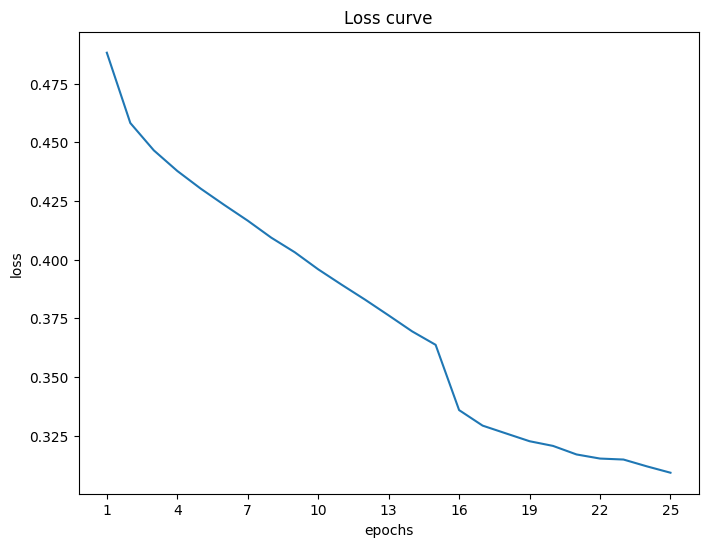

In [95]:
#plotting loss curve for training

x = np.arange(1,26)
y = train_result['loss']

plt.figure(figsize=(8,6))
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Loss curve')
plt.xticks(np.arange(1,42,3))
plt.plot(x, y, label='Loss curve')
plt.savefig('plots/Train loss curve_2.png')
plt.show()


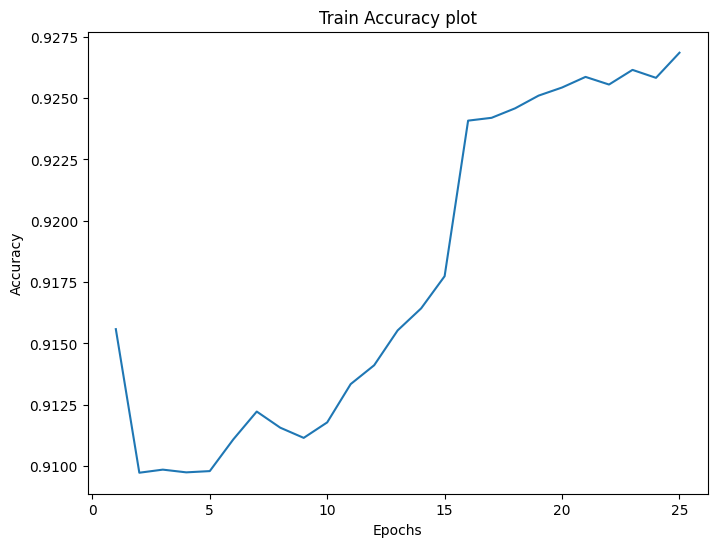

In [94]:
#plotting the accuracy curve

plt.figure(figsize=(8,6))

x = np.arange(1,26,1)
y = train_result['accuracy']

plt.plot(x, y )
plt.title('Train Accuracy plot')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.savefig('Train_accuracy.png')
plt.show()

In [66]:
val_result = pd.read_csv('val_results_3.csv')

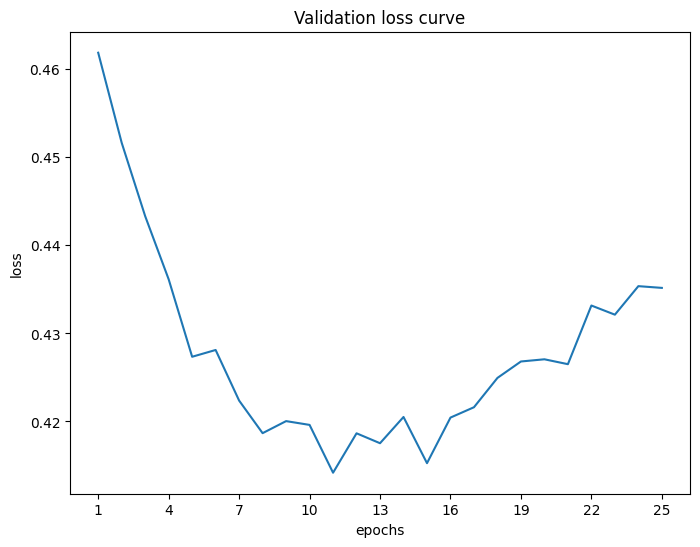

In [93]:
#plotting loss curve for training

x = np.arange(1,26,1)
y = val_result['loss']

plt.figure(figsize=(8,6))
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Validation loss curve')
plt.xticks(np.arange(1,30,3))
plt.plot(x, y, label='Validation loss curve')
plt.savefig('plots/Val loss curve_2.png')
plt.show()


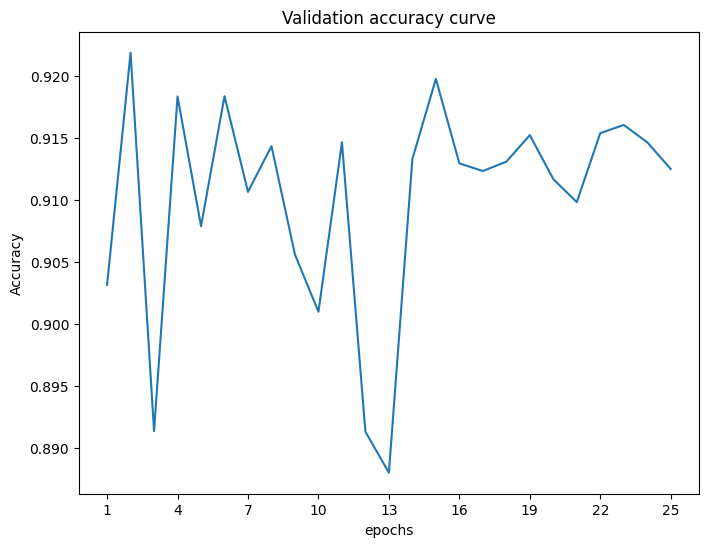

In [92]:
#plotting loss curve for training

x = np.arange(1,26,1)
y = val_result['accuracy']

plt.figure(figsize=(8,6))
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.title('Validation accuracy curve')
plt.xticks(np.arange(1,30,3))
plt.plot(x, y, label='Validation accuracy curve')
plt.savefig('plots/Val accuracy curve_2.png')
plt.show()


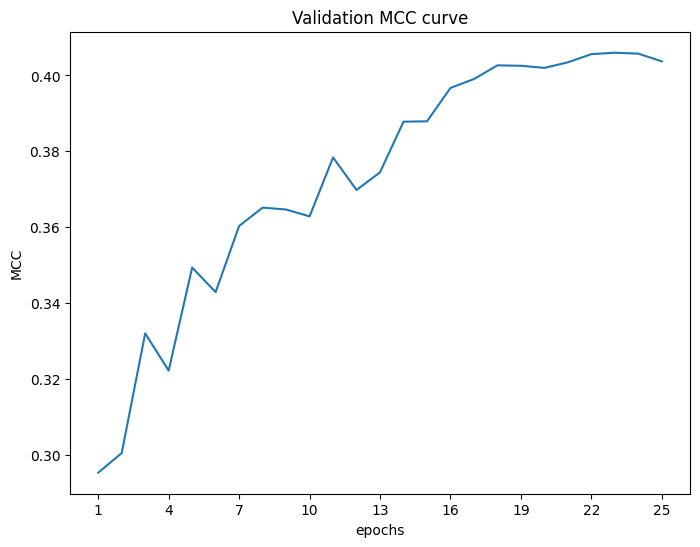

In [91]:
#plotting loss curve for training

x = np.arange(1,26,1)
y = val_result['mcc']

plt.figure(figsize=(8,6))
plt.xlabel('epochs')
plt.ylabel('MCC')
plt.title('Validation MCC curve')
plt.xticks(np.arange(1,30,3))
plt.plot(x, y, label='Validation MCC curve')
plt.savefig('plots/Val MCC curve_2.png')
plt.show()


In [76]:
with torch.no_grad():
    model1.eval()
    for X,y in val_loader:
        X = X.squeeze().to(device)
        y = y.squeeze().float().to(device)

        output = model1(X).squeeze()

        loss = criterion(output, y)

        val_loss+=loss.item()

        temp_recall = 0
        best_t=0
        for t in np.arange(0.35,0.5,0.02):

            #val recall
            true_positive, false_positive = compute_precision(output, y, t)
            val_total_true_positive += true_positive
            false_negative = compute_recall(output, y, t)
            val_total_false_negative += false_negative
            val_epoch_recall = val_total_true_positive/(val_total_true_positive+val_total_false_negative)

            if val_epoch_recall>temp_recall:
                temp_recall=val_epoch_recall
                best_t = t




In [77]:
best_t

np.float64(0.4900000000000001)

In [78]:
# model evaluation loop
model1.eval()

predictions = []
true_labels = []

test_samples = 0
correct_samples = 0
with torch.no_grad():
    
    test_loss = 0.0
    total_true_positive = 0.0
    total_false_positive = 0.0
    total_false_negative = 0.0
    for X, y in test_loader:
        # print(X.shape, y.shape)
        X = X.squeeze().to(device)
        y = y.squeeze().float().to(device)
        
        outputs = model1(X).squeeze()
        probs = torch.sigmoid(outputs)
        
        predictions.extend(probs.cpu().numpy())
        true_labels.extend(y.cpu().numpy())
        
        test_loss += criterion(outputs, y).item()
        
        correct, total = compute_accuracy(outputs, y)
        correct_samples+=correct
        test_samples+=total
        
        true_positive, false_positive = compute_precision(outputs, y)
        total_true_positive += true_positive
        total_false_positive += false_positive
        
        false_negative = compute_recall(outputs, y)
        total_false_negative += false_negative
        # total
    
    val_acc = correct_samples/test_samples
    val_loss = test_loss/len(test_loader)
    val_precision = total_true_positive/(total_true_positive+total_false_positive)
    val_recall = total_true_positive/(total_true_positive+total_false_negative)
    
    print(f'The test accuracy is: {val_acc} | test loss is: {val_loss} | precision is: {val_precision} | recall is: {val_recall}')
        


The test accuracy is: 0.913097125613748 | test loss is: 0.4345128075532164 | precision is: 0.3757663429083144 | recall is: 0.5462647706789505


In [79]:
y_true = np.array(true_labels)
y_probs = np.array(predictions)

In [80]:
regions = combined_test['region'].values

In [81]:
coding_idx = regions==0
noncoding_idx = regions==1

In [82]:
from sklearn.metrics import roc_curve, auc

fpr_c, tpr_c, _ = roc_curve(y_true[coding_idx], y_probs[coding_idx])
auc_c = auc(fpr_c, tpr_c)

In [83]:
fpr_nc, tpr_nc,_ = roc_curve(y_true[noncoding_idx], y_probs[noncoding_idx])
auc_nc = auc(fpr_nc, tpr_nc)

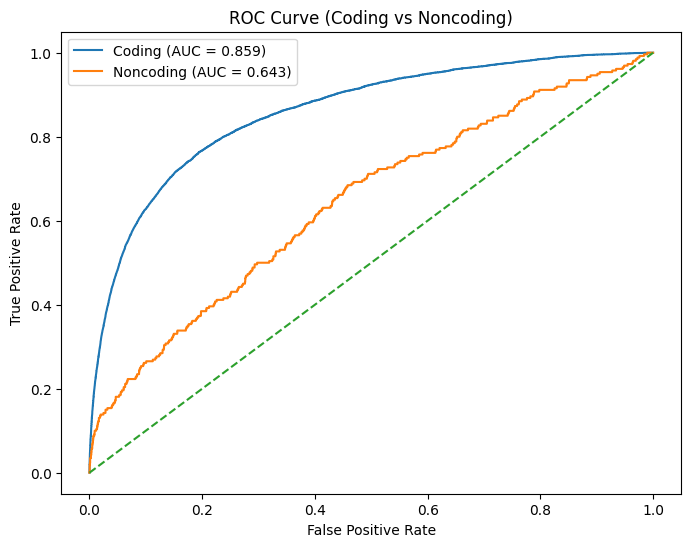

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(fpr_c, tpr_c, label=f'Coding (AUC = {auc_c:.3f})')
plt.plot(fpr_nc, tpr_nc, label=f'Noncoding (AUC = {auc_nc:.3f})')

plt.plot([0,1], [0,1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Coding vs Noncoding)")
plt.legend()
plt.savefig('plots/Regionic_ROC_2.png')
plt.show()


In [85]:
m1 = {'true': true_labels, 'preds': predictions}

val_df = pd.DataFrame(m1)

In [86]:
#plotting the confusion matrix
category = []

for index, row in val_df.iterrows():
    if row['true']==0 and row['preds']<0.5:
        category.append('TN')
    
    elif row['true']==0 and row['preds']>=0.5:
        category.append('FP')
    
    elif row['true']==1 and row['preds']>=0.5:
        category.append('TP')
    
    elif row['true']==1 and row['preds']<0.5:
        category.append('FN')

val_df['category']= category

In [87]:
val_df['category'].value_counts()

category
TN    137368
FP      9062
TP      5455
FN      4531
Name: count, dtype: int64

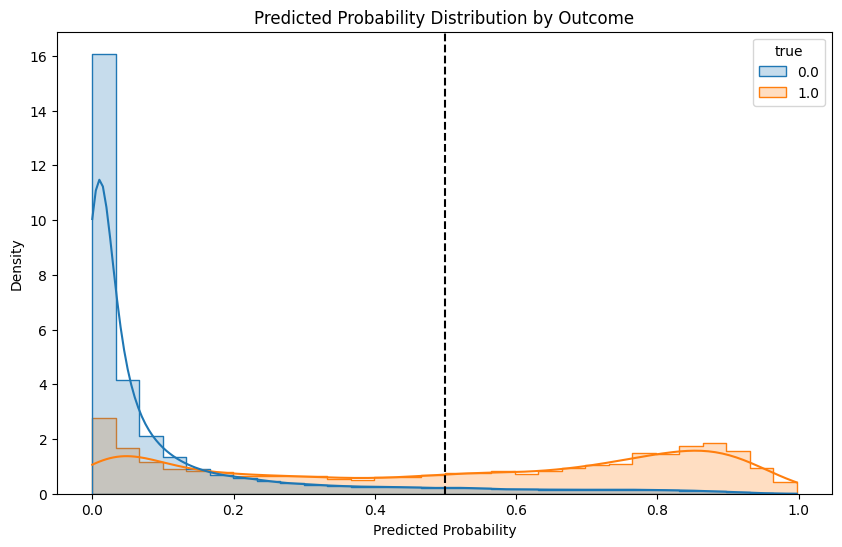

In [88]:
#plotting the confusion matrix
plt.figure(figsize=(10,6))
sns.histplot(data=val_df, x='preds', hue='true',
            element='step', common_norm=False,
            # palette={'TP': 'blue', 'TN': 'green', 
            #           'FP': 'red', 'FN': 'orange'},
             stat='density',
             kde=True, bins=30)
plt.axvline(x=0.5, color='black', linestyle='--')
plt.title('Predicted Probability Distribution by Outcome')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.show()